In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [3]:
from pathlib import Path

# load dataset
data_path = Path("../data/regularite-mensuelle-tgv-aqst.csv")
df = pd.read_csv(data_path, sep=";")

In [6]:
# Dataset overview
print(f"Shape: {df.shape}")
print("\nData types and non-null counts:")
df.info()

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print("\nDescriptive statistics:")
display(df.describe().T)

print("\nCategorical columns:")
for column in df.select_dtypes(include="object").columns:
    print(f"{column}: {df[column].nunique()} unique values")
    if column in ["Date", "Service", "Gare de départ", "Gare d'arrivée"]:
        display(df[column].value_counts().head(10).to_frame("count"))



Shape: (12544, 26)

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 12544 entries, 0 to 12543
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         12544 non-null  str    
 1   Service                                                                                      12544 non-null  str    
 2   Gare de départ                                                                               12544 non-null  str    
 3   Gare d'arrivée                                                                               12544 non-null  str    
 4   Durée moyenne du trajet                                                                      12544 non-null  int6

,missing_count
Commentaire annulations,12544
Commentaire retards au départ,12544
Commentaire retards à l'arrivée,11846



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Durée moyenne du trajet,12544.0,170.628508,87.730733,0.000000,99.000000,163.000000,223.000000,786.000000
Nombre de circulations prévues,12544.0,272.623884,183.559230,0.000000,151.000000,230.000000,362.000000,1100.000000
Nombre de trains annulés,12544.0,8.407685,22.089205,0.000000,0.000000,2.000000,7.000000,297.000000
Commentaire annulations,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard au départ,12544.0,86.219866,88.428503,0.000000,22.000000,52.000000,126.000000,596.000000
Retard moyen des trains en retard au départ,12544.0,12.499854,11.660090,0.000000,6.346596,10.560933,16.101225,316.188095
Retard moyen de tous les trains au départ,12544.0,3.175135,5.054562,-229.269444,1.226076,2.368000,4.031985,115.047390
Commentaire retards au départ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nombre de trains en retard à l'arrivée,12544.0,38.243304,31.826539,0.000000,16.000000,30.000000,52.000000,376.000000
Retard moyen des trains en retard à l'arrivée,12544.0,35.471909,15.605191,-40.109259,25.958062,33.777423,42.776681,299.600000



Categorical columns:
Date: 102 unique values


...

Gare de départ: 59 unique values


,count
Gare de départ,
PARIS LYON,2560
PARIS MONTPARNASSE,1632
LYON PART DIEU,615
PARIS EST,615
MARSEILLE ST CHARLES,557
PARIS NORD,408
LILLE,306
RENNES,216
NANTES,216


Gare d'arrivée: 59 unique values


,count
Gare d'arrivée,
PARIS LYON,2560
PARIS MONTPARNASSE,1632
PARIS EST,615
LYON PART DIEU,615
MARSEILLE ST CHARLES,469
PARIS NORD,408
LILLE,306
NANTES,216
RENNES,216


Commentaire retards à l'arrivée: 302 unique values


array([<Axes: xlabel='_date'>, <Axes: xlabel='_date'>,
       <Axes: xlabel='_date'>, <Axes: xlabel='_date'>,
       <Axes: xlabel='_date'>], dtype=object)

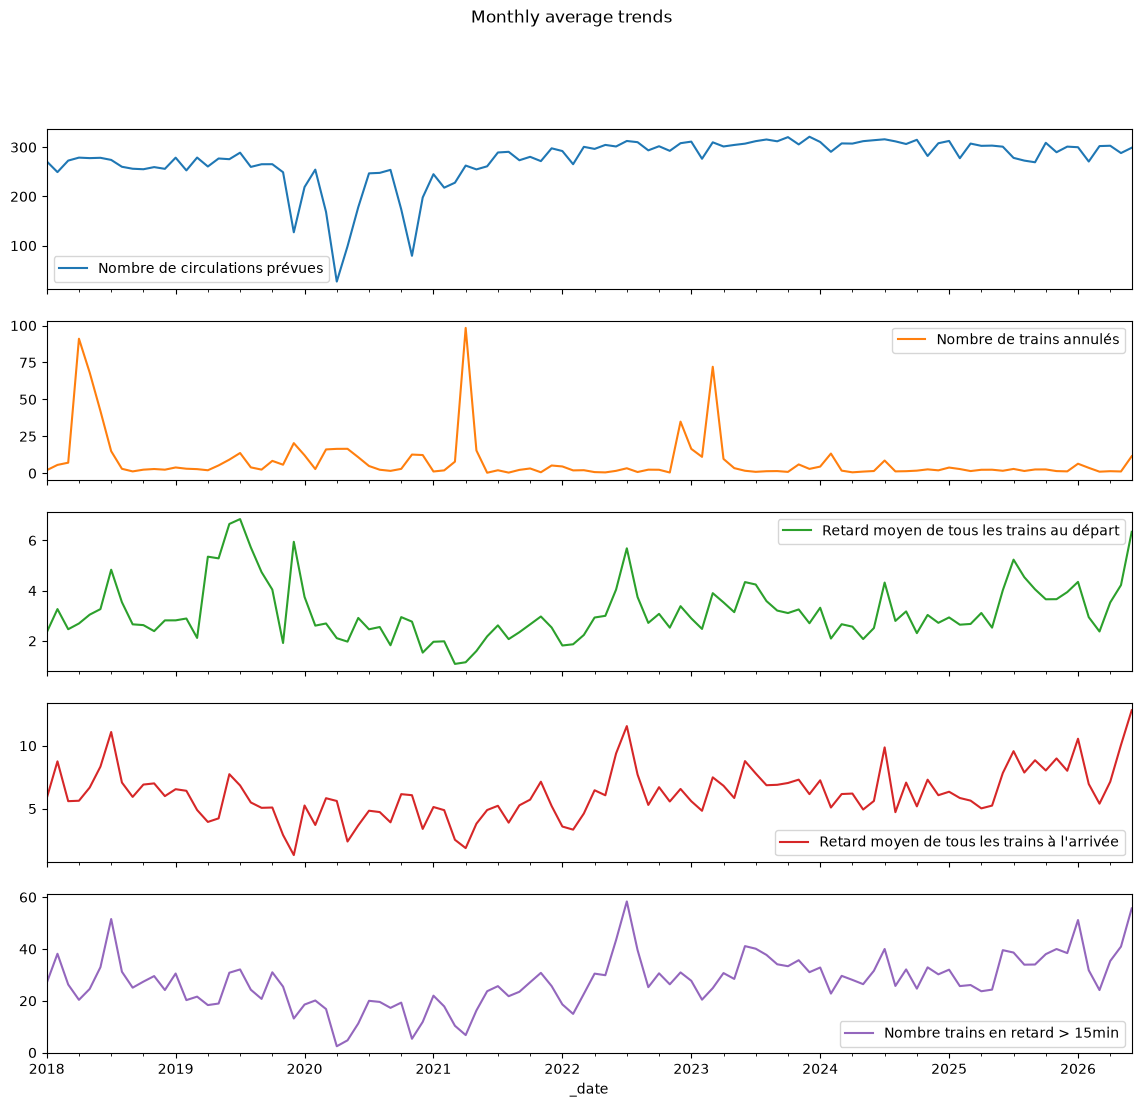

In [7]:
# Convert dates and create monthly summaries
dates = pd.to_datetime(df["Date"], format="%Y-%m", errors="coerce")

metrics = [
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Retard moyen de tous les trains au départ",
    "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min",
]

monthly = (
    df.assign(_date=dates)
      .groupby("_date")[metrics]
      .mean()
)

# Monthly trends
monthly.plot(
    subplots=True,
    figsize=(14, 12),
    sharex=True,
    title="Monthly average trends"
)



__Les liaisons les moins fiables du réseau, et cette instabilité s'aggrave-t-elle ou s'améliore-t-elle dans le temps ?__

In [13]:
# Analyse des liaisons les moins fiables et de leur évolution temporelle
route_cols = ["Gare de départ", "Gare d'arrivée"]
arrival_delay = "Retard moyen de tous les trains à l'arrivée"
late_15 = "Nombre trains en retard > 15min"
planned = "Nombre de circulations prévues"
cancelled = "Nombre de trains annulés"

analysis = (
    df.assign(_date=dates, _route=df["Gare de départ"] + " → " + df["Gare d'arrivée"])
      .groupby("_route")
      .agg(
          mois=("_date", "nunique"),
          circulations=(planned, "sum"),
          retard_arrivee=(arrival_delay, "mean"),
          trains_retard_15=(late_15, "sum"),
          annulations=(cancelled, "sum"),
      )
)

analysis["taux_retard_15"] = 100 * analysis["trains_retard_15"] / analysis["circulations"]
analysis["taux_annulation"] = 100 * analysis["annulations"] / analysis["circulations"]

# On conserve les liaisons suffisamment représentées
reliable_routes = analysis.query("mois >= 12 and circulations >= 1000").copy()

reliable_routes["rang_retard"] = reliable_routes["retard_arrivee"].rank(ascending=False)
reliable_routes["rang_retard_15"] = reliable_routes["taux_retard_15"].rank(ascending=False)
reliable_routes["score_fiabilite"] = (
    reliable_routes["rang_retard"] + reliable_routes["rang_retard_15"]
)

print("Liaisons les moins fiables selon le retard moyen à l'arrivée :")
display(
    reliable_routes.sort_values("retard_arrivee", ascending=False)
    [["mois", "circulations", "retard_arrivee", "taux_retard_15", "taux_annulation"]]
    .head(10)
    .round(2)
)

print("Liaisons les moins fiables selon un classement combiné :")
display(
    reliable_routes.sort_values("score_fiabilite")
    [["mois", "circulations", "retard_arrivee", "taux_retard_15", "taux_annulation"]]
    .head(10)
    .round(2)
)

# Evolution mensuelle par liaison
route_monthly = (
    df.assign(
        _date=dates,
        _route=df["Gare de départ"] + " → " + df["Gare d'arrivée"]
    )
    .groupby(["_route", "_date"])
    .agg(
        retard_arrivee=(arrival_delay, "mean"),
        circulations=(planned, "sum"),
        retard_15=(late_15, "sum"),
    )
)

route_monthly["taux_retard_15"] = (
    100 * route_monthly["retard_15"] / route_monthly["circulations"]
)

trends = []
for route, group in route_monthly.groupby(level=0):
    group = group.reset_index().sort_values("_date")
    if len(group) >= 12:
        x = np.arange(len(group))
        slope_delay = np.polyfit(x, group["retard_arrivee"], 1)[0]
        slope_rate = np.polyfit(x, group["taux_retard_15"], 1)[0]
        trends.append([route, len(group), slope_delay * 12, slope_rate * 12])

trends = pd.DataFrame(
    trends,
    columns=["liaison", "mois", "variation_retard_min_par_an",
             "variation_taux_retard_15_points_par_an"]
).set_index("liaison")

print("Liaisons dont l'instabilité s'aggrave le plus :")
display(
    trends.sort_values("variation_retard_min_par_an", ascending=False)
    .head(10)
    .round(2)
)

print("Liaisons qui s'améliorent le plus :")
display(
    trends.sort_values("variation_retard_min_par_an")
    .head(10)
    .round(2)
)

# Evolution globale du réseau
network_trend = monthly[[arrival_delay]].copy()
slope = np.polyfit(
    np.arange(len(network_trend)),
    network_trend[arrival_delay],
    1
)[0] * 12

print(
    f"Evolution moyenne du retard à l'arrivée : "
    f"{slope:.2f} minute(s) par an."
)
print(
    "Conclusion : l'instabilité s'aggrave à l'échelle du réseau."
    if slope > 0
    else "Conclusion : l'instabilité s'améliore à l'échelle du réseau."
)

Liaisons les moins fiables selon le retard moyen à l'arrivée :


,mois,circulations,retard_arrivee,taux_retard_15,taux_annulation
_route,,,,,
ITALIE → PARIS LYON,98,7011,14.34,31.28,4.45
MARSEILLE ST CHARLES → TOURCOING,101,2513,11.12,18.46,3.10
MARSEILLE ST CHARLES → LILLE,102,19390,10.97,20.88,3.65
PARIS EST → STUTTGART,102,12457,10.91,21.87,3.50
LYON PART DIEU → LILLE,102,29092,10.89,20.83,4.23
BARCELONA → PARIS LYON,102,5738,10.87,20.25,1.97
CHAMBERY CHALLES LES EAUX → PARIS LYON,102,21904,10.36,21.56,3.34
TOULOUSE MATABIAU → PARIS MONTPARNASSE,102,19078,10.22,15.80,2.92
LILLE → MARSEILLE ST CHARLES,102,20952,10.09,18.06,3.20


Liaisons les moins fiables selon un classement combiné :


,mois,circulations,retard_arrivee,taux_retard_15,taux_annulation
_route,,,,,
ITALIE → PARIS LYON,98,7011,14.34,31.28,4.45
PARIS EST → STUTTGART,102,12457,10.91,21.87,3.50
MARSEILLE ST CHARLES → LILLE,102,19390,10.97,20.88,3.65
CHAMBERY CHALLES LES EAUX → PARIS LYON,102,21904,10.36,21.56,3.34
LYON PART DIEU → LILLE,102,29092,10.89,20.83,4.23
MARSEILLE ST CHARLES → TOURCOING,101,2513,11.12,18.46,3.10
BARCELONA → PARIS LYON,102,5738,10.87,20.25,1.97
LILLE → MARSEILLE ST CHARLES,102,20952,10.09,18.06,3.20
MACON LOCHE → PARIS LYON,102,22437,9.28,19.51,3.15


Liaisons dont l'instabilité s'aggrave le plus :


,mois,variation_retard_min_par_an,variation_taux_retard_15_points_par_an
liaison,,,
PARIS VAUGIRARD → RENNES,12,14.55,11.67
PARIS VAUGIRARD → NANTES,12,6.17,13.03
PARIS EST → STUTTGART,102,2.00,NaN
STRASBOURG → NANTES,102,1.47,NaN
NIMES → PARIS LYON,102,1.28,0.08
MONTPELLIER → PARIS LYON,102,1.25,0.12
PARIS EST → FRANCFORT,102,1.25,NaN
LYON PART DIEU → MONTPELLIER,102,1.13,0.60
VALENCE ALIXAN TGV → PARIS LYON,102,0.96,0.00


Liaisons qui s'améliorent le plus :


,mois,variation_retard_min_par_an,variation_taux_retard_15_points_par_an
liaison,,,
PARIS VAUGIRARD → BORDEAUX ST JEAN,12,-4.92,-7.68
MADRID → MARSEILLE ST CHARLES,45,-1.88,NaN
MARSEILLE ST CHARLES → MADRID,45,-1.44,NaN
BORDEAUX ST JEAN → PARIS VAUGIRARD,12,-1.23,-1.86
NANTES → PARIS VAUGIRARD,12,-1.18,2.66
RENNES → PARIS VAUGIRARD,12,-0.90,-0.79
LYON PART DIEU → RENNES,102,-0.75,NaN
TOURCOING → BORDEAUX ST JEAN,100,-0.74,NaN
PARIS LYON → BARCELONA,102,-0.50,-1.16


Evolution moyenne du retard à l'arrivée : 0.28 minute(s) par an.
Conclusion : l'instabilité s'aggrave à l'échelle du réseau.


**Les causes de retard varient-elles selon la saison (travaux l'été, intempéries l'hiver, affluence lors des vacances scolaires) ?**

Répartition moyenne pondérée des causes de retard (%) :


,Causes externes,Infrastructure,Gestion du trafic,Matériel roulant,Gestion en gare,Voyageurs / affluence
Hiver,2421.50,2038.48,2216.19,1872.92,734.61,716.30
Printemps,2243.54,2256.86,1987.24,1817.72,853.63,802.93
Été,2031.06,2030.42,2033.42,1972.36,984.19,834.09
Automne,2025.18,2159.79,2353.29,1839.28,817.52,802.79


Indicateurs de retard par saison :


,retard_arrivee,taux_annulation,trains_retardes
Saison,,,
Hiver,5.73,22406,118108
Printemps,5.42,55690,105555
Été,7.39,18445,140038
Automne,6.32,8925,116023


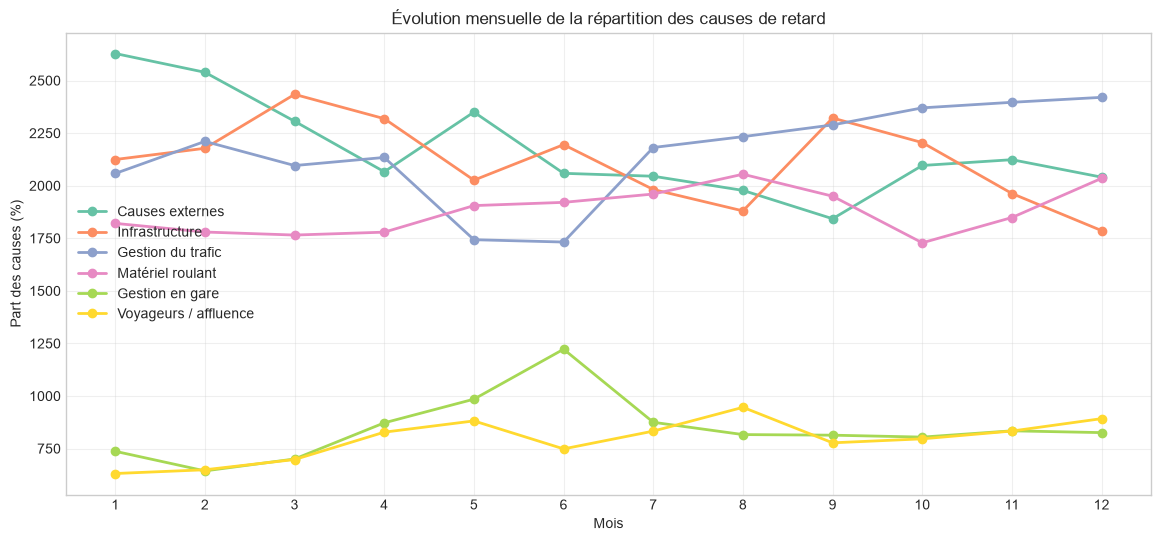

Cause dominante par saison :


,cause_dominante
Hiver,Causes externes
Printemps,Infrastructure
Été,Gestion du trafic
Automne,Gestion du trafic


In [16]:
# Analyse saisonnière des causes de retard
import matplotlib.pyplot as plt

cause_cols = [
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",
]

cause_labels = {
    cause_cols[0]: "Causes externes",
    cause_cols[1]: "Infrastructure",
    cause_cols[2]: "Gestion du trafic",
    cause_cols[3]: "Matériel roulant",
    cause_cols[4]: "Gestion en gare",
    cause_cols[5]: "Voyageurs / affluence",
}

season_map = {
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne",
}

season_order = ["Hiver", "Printemps", "Été", "Automne"]

seasonal_df = df.copy()
seasonal_df["_date"] = dates
seasonal_df["_mois"] = seasonal_df["_date"].dt.month
seasonal_df["Saison"] = seasonal_df["_mois"].map(season_map)

# Pondération par le nombre de trains effectivement retardés à l'arrivée
delayed = "Nombre de trains en retard à l'arrivée"
seasonal_df["_trains_retardes"] = seasonal_df[delayed].clip(lower=0)

seasonal_causes = {}
for cause in cause_cols:
    seasonal_df[f"_{cause}"] = (
        seasonal_df[cause].fillna(0) * seasonal_df["_trains_retardes"]
    )

for season in season_order:
    subset = seasonal_df[seasonal_df["Saison"] == season]
    total_delayed = subset["_trains_retardes"].sum()
    seasonal_causes[season] = {
        cause_labels[cause]: 100 * subset[f"_{cause}"].sum() / total_delayed
        for cause in cause_cols
    }

seasonal_causes = pd.DataFrame(seasonal_causes).T[cause_labels.values()]

print("Répartition moyenne pondérée des causes de retard (%) :")
display(seasonal_causes.round(2))

# Comparaison des indicateurs de retard
seasonal_delays = (
    seasonal_df.groupby("Saison")
    .agg(
        retard_arrivee=(arrival_delay, "mean"),
        taux_annulation=(cancelled, "sum"),
        trains_retardes=("_trains_retardes", "sum"),
    )
    .reindex(season_order)
)

print("Indicateurs de retard par saison :")
display(seasonal_delays.round(2))

# Évolution mensuelle des principales causes
monthly_causes = {}
for cause in cause_cols:
    numerator = seasonal_df.groupby("_mois")[f"_{cause}"].sum()
    denominator = seasonal_df.groupby("_mois")["_trains_retardes"].sum()
    monthly_causes[cause_labels[cause]] = 100 * numerator / denominator

monthly_causes = pd.DataFrame(monthly_causes).sort_index()

ax = monthly_causes.plot(
    figsize=(14, 6),
    marker="o",
    linewidth=2,
    title="Évolution mensuelle de la répartition des causes de retard"
)
ax.set_xlabel("Mois")
ax.set_ylabel("Part des causes (%)")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)
plt.show()

# Cause dominante selon la saison
dominant_causes = seasonal_causes.idxmax(axis=1)
print("Cause dominante par saison :")
display(dominant_causes.to_frame("cause_dominante"))

*Conclusion : les causes de retard varient selon la saison.* 

**Les causes externes et l'infrastructure peuvent être comparées aux périodes hivernales et estivales, tandis que la cause liée aux voyageurs constitue un indicateur indirect de l'effet de l'affluence.**


**Le jeu de données ne contient toutefois pas de calendrier explicite des travaux, intempéries ou vacances scolaires : ces interprétations restent des associations saisonnières et non des preuves de causalité.**